# Demo: Market-Depth and Moving-Window Representations

This notebook samples a small number of limit-order-book snapshots from: `data/raw/XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst` using a fixed time interval.

It then creates two sequence representations from `src/features/representation.py`:
- `moving_window`
- `market_depth`

In [61]:
from __future__ import annotations

from types import SimpleNamespace
from pathlib import Path

import databento as db
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.features.representation import RepresentationTransform
from src.lob_implementation import Market, Book, LevelOrders

In [62]:
sampling_interval_s = 0.1   # time gap between sampled snapshots
total_intervals = 20        # total number of snapshots to sample
max_messages = 2_000_000    # safety stop for demo runtime

dbn_path = Path('../data') / 'raw' / 'XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst'

In [63]:
def _snapshot_book(book: Book) -> Book:
    """Create a Book snapshot with only price/size information.

    This is to solve the problem of the book object being mutable but I can't deepcopy it...
    """
    snap = Book()

    for px, level in book.bids.items():
        size = int(level.level.size)
        if size <= 0:
            continue
        lv = LevelOrders(price=int(px))
        lv.orders = [SimpleNamespace(size=size, flags=0)]
        snap.bids[int(px)] = lv

    for px, level in book.offers.items():
        size = int(level.level.size)
        if size <= 0:
            continue
        lv = LevelOrders(price=int(px))
        lv.orders = [SimpleNamespace(size=size, flags=0)]
        snap.offers[int(px)] = lv

    return snap

# pre-processing copied from order_tracking.py
def sample_books_from_dbn(
    file_path: Path,
    sampling_interval_s: float,
    total_intervals: int,
) -> tuple[list[Book], list[int]]:
    """Sample Book snapshots from a DBN stream at fixed time intervals beginning at day_start_dt."""
    store = db.DBNStore.from_file(str(file_path))
    market = Market()

    sampled_books: list[Book] = []
    sampled_ts: list[int] = []

    interval_ns = int(sampling_interval_s * 1e9)

    next_sample_ts: int | None = None

    current_day = None
    day_start_ns: int | None = None
    day_end_ns: int | None = None

    for idx, mbo in enumerate(store, start=1):

        market.apply(mbo)
        ts = int(mbo.ts_event)

        msg_day = int(ts // (86400 * 1e9))
        if msg_day != current_day:
            ts_dt = pd.to_datetime(ts, unit='ns', utc=True).tz_convert('America/New_York')
            local_midnight = pd.Timestamp(ts_dt.date()).tz_localize('America/New_York')
            day_start_dt = local_midnight + pd.Timedelta(hours=10, minutes=30)  # modify this to start sampling at a different time
            day_end_dt = local_midnight + pd.Timedelta(hours=16, minutes=0)
            day_start_ns = int(day_start_dt.tz_convert('UTC').value)
            day_end_ns = int(day_end_dt.tz_convert('UTC').value)
            current_day = msg_day

        if day_start_ns is None or day_end_ns is None:
            continue
        if ts < day_start_ns or ts > day_end_ns:
            continue

        book = market.get_book(mbo.instrument_id, mbo.publisher_id)

        best_bid, best_ask = book.bbo()
        if not best_bid or not best_ask:
            continue

        if next_sample_ts is None:
            next_sample_ts = ts

        if ts >= next_sample_ts:
            sampled_books.append(_snapshot_book(book))
            sampled_ts.append(ts)
            next_sample_ts += interval_ns

            if len(sampled_books) >= total_intervals:
                break

    return sampled_books, sampled_ts

In [64]:
sampled_books, sampled_ts = sample_books_from_dbn(
    file_path=dbn_path,
    sampling_interval_s=sampling_interval_s,
    total_intervals=total_intervals
)

In [65]:
# Representation parameters
window = 20
tick_size = int(0.01 * 1e9)  # 1 cent in Databento fixed-price units

moving_transform = RepresentationTransform(
    window=window,
    tick_size=tick_size,
    representation='moving_window',
)

depth_transform = RepresentationTransform(
    window=window,
    tick_size=tick_size,
    representation='market_depth',
)

moving_tensor = moving_transform.transform_sequence(sampled_books)
depth_tensor = depth_transform.transform_sequence(sampled_books)

print('moving_window shape:', tuple(moving_tensor.shape))
print('market_depth shape:', tuple(depth_tensor.shape))

moving_window shape: (20, 41)
market_depth shape: (20, 41)


In [66]:
offsets = list(range(-window, window + 1))

moving_df = pd.DataFrame({
    'offset': offsets,
    'signed_volume': moving_tensor[0].tolist(),
})

depth_df = pd.DataFrame({
    'offset': offsets,
    'cumulative_signed_depth': depth_tensor[0].tolist(),
})

print('First moving-window snapshot:')
display(moving_df)

print('First market-depth snapshot:')
display(depth_df)

First moving-window snapshot:


,offset,signed_volume
0,-20,-110.0
1,-19,-124.0
2,-18,-119.0
3,-17,-139.0
4,-16,-162.0
5,-15,-225.0
6,-14,-100.0
7,-13,-547.0
8,-12,-119.0
9,-11,-104.0


First market-depth snapshot:


,offset,cumulative_signed_depth
0,-20,-4005.0
1,-19,-3895.0
2,-18,-3771.0
3,-17,-3652.0
4,-16,-3513.0
5,-15,-3351.0
6,-14,-3126.0
7,-13,-3026.0
8,-12,-2479.0
9,-11,-2360.0


c:\Users\AngusCheung\anaconda3\envs\lob\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
c:\Users\AngusCheung\anaconda3\envs\lob\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


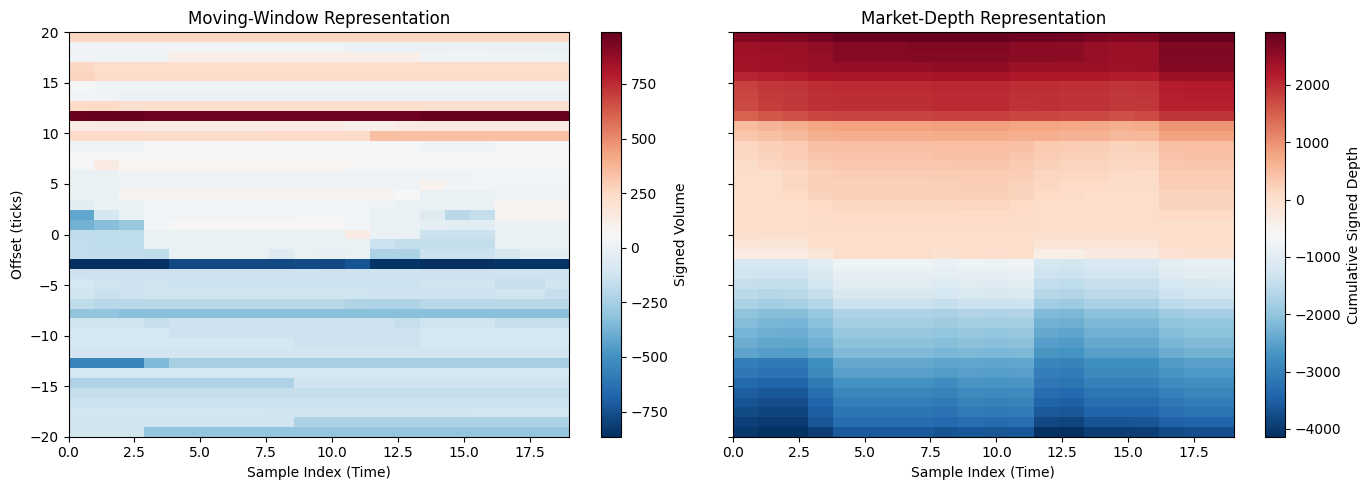

In [67]:
offsets = np.arange(-window, window + 1)
times_utc = pd.to_datetime(sampled_ts, unit='ns', utc=True)
times_et = times_utc.tz_convert('America/New_York')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im0 = axes[0].imshow(moving_tensor.T, aspect='auto', origin='lower',
                    extent=[0, len(times_et)-1, offsets[0], offsets[-1]],
                    cmap='RdBu_r')
axes[0].set_title('Moving-Window Representation')
axes[0].set_xlabel('Sample Index (Time)')
axes[0].set_ylabel('Offset (ticks)')
fig.colorbar(im0, ax=axes[0], label='Signed Volume')

im1 = axes[1].imshow(depth_tensor.T, aspect='auto', origin='lower',
                    extent=[0, len(times_et)-1, offsets[0], offsets[-1]],
                    cmap='RdBu_r')
axes[1].set_title('Market-Depth Representation')
axes[1].set_xlabel('Sample Index (Time)')
fig.colorbar(im1, ax=axes[1], label='Cumulative Signed Depth')

plt.tight_layout()
plt.show()